# Independence

**Independence** is one of the most important properties in probability. Two events are independent if knowing the outcome of one **does not change** your belief about whether the other will occur.

- **Definition** — $P(E|F) = P(E)$
- **Alternative Definition** — $P(A, B) = P(A) \cdot P(B)$
- **Symmetry** — If $E$ is independent of $F$, then $F$ is independent of $E$
- **Generalized Independence** — Extending to $n$ events
- **Independence and Complements** — If $A \perp B$, then $A \perp B^C$
- **Parallel Networks** — A classic application
- **Conditional Independence** — Independence within a conditioned universe
- **Independence vs. Mutual Exclusion** — Two very different properties

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Independence](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/independence/)

## Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgba
from itertools import combinations

from libs.venn import venn, Color

np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## 1. Definition of Independence

Two events $E$ and $F$ are **independent** if:

> $$\boxed{P(E|F) = P(E)}$$

In words: learning that $F$ occurred **does not change** the probability of $E$.

**Example:** Two separate dice rolls. The outcome of the first die tells you nothing about the second.

We write $E \perp F$ to denote independence.

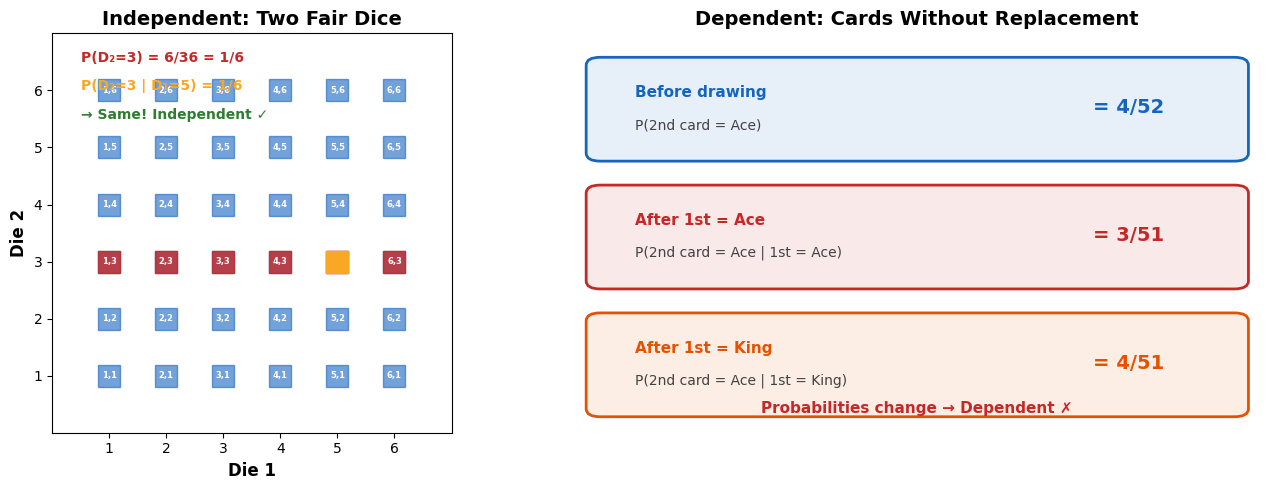

Independent: P(E|F) = P(E) — knowing F doesn't help.
Dependent:   P(E|F) ≠ P(E) — knowing F changes our belief about E.


In [2]:
# --- Visual: Independent vs Dependent dice ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Two fair dice (independent)
ax = axes[0]
ax.set_title('Independent: Two Fair Dice', fontsize=14, fontweight='bold')
ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.set_xlabel('Die 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Die 2', fontsize=12, fontweight='bold')

# All outcomes equally likely
for d1 in range(1, 7):
    for d2 in range(1, 7):
        ax.plot(d1, d2, 's', color='#1565C0', markersize=16, alpha=0.6)
        ax.text(d1, d2, f'{d1},{d2}', ha='center', va='center',
                fontsize=6, color='white', fontweight='bold')

# Highlight: P(D2=3) vs P(D2=3 | D1=5)
for d1 in range(1, 7):
    ax.plot(d1, 3, 's', color='#C62828', markersize=16, alpha=0.8)
ax.plot(5, 3, 's', color='#F9A825', markersize=16, zorder=5)
ax.text(5, 3, '★', ha='center', va='center', fontsize=10, color='#C62828')

ax.text(0.5, 6.5, 'P(D₂=3) = 6/36 = 1/6', fontsize=10, color='#C62828',
        fontweight='bold')
ax.text(0.5, 6.0, 'P(D₂=3 | D₁=5) = 1/6', fontsize=10, color='#F9A825',
        fontweight='bold')
ax.text(0.5, 5.5, '→ Same! Independent ✓', fontsize=10, color='#2E7D32',
        fontweight='bold')

ax.set_xticks(range(1, 7))
ax.set_yticks(range(1, 7))
ax.set_aspect('equal')

# Right panel: Dependent example - drawing cards without replacement
ax = axes[1]
ax.set_title('Dependent: Cards Without Replacement', fontsize=14, fontweight='bold')
ax.axis('off')

# Draw scenario
scenarios = [
    ('Before drawing', 'P(2nd card = Ace)', '4/52', '#1565C0'),
    ('After 1st = Ace', 'P(2nd card = Ace | 1st = Ace)', '3/51', '#C62828'),
    ('After 1st = King', 'P(2nd card = Ace | 1st = King)', '4/51', '#E65100'),
]

for i, (scenario, formula, value, color) in enumerate(scenarios):
    y = 0.78 - i * 0.32
    rect = FancyBboxPatch((0.05, y - 0.08), 0.9, 0.22,
        boxstyle='round,pad=0.02', facecolor=to_rgba(color, 0.1),
        edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(0.1, y + 0.06, scenario, fontsize=11, fontweight='bold',
            color=color, transform=ax.transAxes)
    ax.text(0.1, y - 0.02, formula, fontsize=10,
            color='#424242', transform=ax.transAxes)
    ax.text(0.85, y + 0.02, f'= {value}', fontsize=14, fontweight='bold',
            ha='right', color=color, transform=ax.transAxes)

ax.text(0.5, 0.05, 'Probabilities change → Dependent ✗', fontsize=11,
        ha='center', fontweight='bold', color='#C62828', transform=ax.transAxes)

plt.tight_layout()
plt.show()

print("Independent: P(E|F) = P(E) — knowing F doesn't help.")
print("Dependent:   P(E|F) ≠ P(E) — knowing F changes our belief about E.")

---

## 2. Alternative Definition — The Product Rule

Using the chain rule $P(A, B) = P(A) \cdot P(B|A)$ and substituting $P(B|A) = P(B)$ (independence):

> **Product Rule for Independence:**
>
> $$\boxed{P(A, B) = P(A) \cdot P(B)} \quad \text{if and only if } A \perp B$$

This is often the **most practical** way to check or use independence.

In [3]:
# --- Checking independence with the product rule on a fair die ---

S = set(range(1, 7))  # {1, 2, 3, 4, 5, 6}

# Define events
E = {2, 4, 6}    # even numbers
F = {1, 2, 3}    # numbers ≤ 3
G = {1, 2}        # numbers ≤ 2

def P(event):
    return len(event) / len(S)

print("Checking Independence on a Fair Die (S = {1,2,3,4,5,6})")
print("=" * 60)

# Test E and F
E_and_F = E & F
print(f"\nE = even = {E},  F = ≤3 = {F}")
print(f"  P(E) = {P(E):.4f}")
print(f"  P(F) = {P(F):.4f}")
print(f"  P(E)·P(F) = {P(E)*P(F):.4f}")
print(f"  P(E ∩ F) = P({E_and_F}) = {P(E_and_F):.4f}")
print(f"  P(E ∩ F) == P(E)·P(F)? {abs(P(E_and_F) - P(E)*P(F)) < 1e-10} → "
      f"{'Independent ✓' if abs(P(E_and_F) - P(E)*P(F)) < 1e-10 else 'Dependent ✗'}")

# Test E and G
E_and_G = E & G
print(f"\nE = even = {E},  G = ≤2 = {G}")
print(f"  P(E) = {P(E):.4f}")
print(f"  P(G) = {P(G):.4f}")
print(f"  P(E)·P(G) = {P(E)*P(G):.4f}")
print(f"  P(E ∩ G) = P({E_and_G}) = {P(E_and_G):.4f}")
print(f"  P(E ∩ G) == P(E)·P(G)? {abs(P(E_and_G) - P(E)*P(G)) < 1e-10} → "
      f"{'Independent ✓' if abs(P(E_and_G) - P(E)*P(G)) < 1e-10 else 'Dependent ✗'}")

Checking Independence on a Fair Die (S = {1,2,3,4,5,6})

E = even = {2, 4, 6},  F = ≤3 = {1, 2, 3}
  P(E) = 0.5000
  P(F) = 0.5000
  P(E)·P(F) = 0.2500
  P(E ∩ F) = P({2}) = 0.1667
  P(E ∩ F) == P(E)·P(F)? False → Dependent ✗

E = even = {2, 4, 6},  G = ≤2 = {1, 2}
  P(E) = 0.5000
  P(G) = 0.3333
  P(E)·P(G) = 0.1667
  P(E ∩ G) = P({2}) = 0.1667
  P(E ∩ G) == P(E)·P(G)? True → Independent ✓


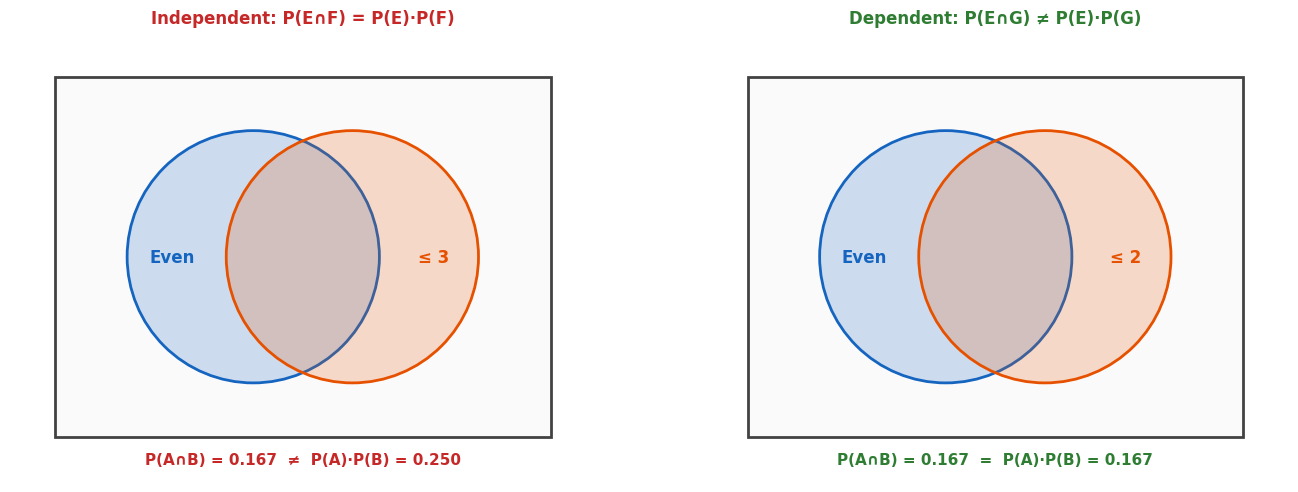

In [4]:
# --- Visual: Venn diagrams for independent vs dependent events ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (A, B, A_label, B_label, title) in enumerate([
    (E, F, 'Even', '≤ 3', 'Independent: P(E∩F) = P(E)·P(F)'),
    (E, G, 'Even', '≤ 2', 'Dependent: P(E∩G) ≠ P(E)·P(G)'),
]):
    ax = axes[ax_idx]
    ax.set_xlim(-0.5, 6)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # Sample space
    rect = patches.Rectangle((0, 0), 5.5, 4, lw=2,
                              edgecolor='#424242', facecolor='#FAFAFA')
    ax.add_patch(rect)

    # Draw circles
    cA = plt.Circle((2.2, 2.0), 1.4, color='#1565C0', alpha=0.2)
    cA_border = plt.Circle((2.2, 2.0), 1.4, fill=False, edgecolor='#1565C0', lw=2)
    cB = plt.Circle((3.3, 2.0), 1.4, color='#E65100', alpha=0.2)
    cB_border = plt.Circle((3.3, 2.0), 1.4, fill=False, edgecolor='#E65100', lw=2)
    ax.add_patch(cA); ax.add_patch(cA_border)
    ax.add_patch(cB); ax.add_patch(cB_border)

    ax.text(1.3, 2.0, A_label, fontsize=12, fontweight='bold', color='#1565C0',
            ha='center', va='center')
    ax.text(4.2, 2.0, B_label, fontsize=12, fontweight='bold', color='#E65100',
            ha='center', va='center')

    # Numbers
    P_AB = P(A & B)
    P_A_times_B = P(A) * P(B)
    color = '#2E7D32' if abs(P_AB - P_A_times_B) < 1e-10 else '#C62828'
    symbol = '=' if abs(P_AB - P_A_times_B) < 1e-10 else '≠'

    ax.text(2.75, -0.3,
            f'P(A∩B) = {P_AB:.3f}  {symbol}  P(A)·P(B) = {P_A_times_B:.3f}',
            fontsize=11, ha='center', color=color, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

---

## 3. Independence is Symmetric

If $E$ is independent of $F$, then $F$ is independent of $E$.

**Proof** (using Bayes' Theorem):

$$P(E|F) = \frac{P(F|E) \cdot P(E)}{P(F)} \stackrel{\text{if } P(F|E)=P(F)}{=} \frac{P(F) \cdot P(E)}{P(F)} = P(E) \;\checkmark$$

So we simply write $E \perp F$ without specifying direction.

In [5]:
# --- Demonstrate symmetry with dice ---

# Use E=even, G=≤2 which ARE independent
print("Symmetry of Independence")
print("=" * 50)
print(f"E = even = {E},  G = ≤2 = {G}")
print()

P_E_val = P(E)
P_G_val = P(G)
P_EG_val = P(E & G)

P_E_given_G = P_EG_val / P_G_val
P_G_given_E = P_EG_val / P_E_val

print(f"Direction 1: P(E|G) = P(E∩G)/P(G) = {P_EG_val:.4f}/{P_G_val:.4f} = {P_E_given_G:.4f}")
print(f"             P(E)   = {P_E_val:.4f}")
print(f"             P(E|G) = P(E)? {abs(P_E_given_G - P_E_val) < 1e-10} ✓")
print()
print(f"Direction 2: P(G|E) = P(E∩G)/P(E) = {P_EG_val:.4f}/{P_E_val:.4f} = {P_G_given_E:.4f}")
print(f"             P(G)   = {P_G_val:.4f}")
print(f"             P(G|E) = P(G)? {abs(P_G_given_E - P_G_val) < 1e-10} ✓")
print()
print("Independence is symmetric: E ⊥ G  ⟺  G ⊥ E")

Symmetry of Independence
E = even = {2, 4, 6},  G = ≤2 = {1, 2}

Direction 1: P(E|G) = P(E∩G)/P(G) = 0.1667/0.3333 = 0.5000
             P(E)   = 0.5000
             P(E|G) = P(E)? True ✓

Direction 2: P(G|E) = P(E∩G)/P(E) = 0.1667/0.5000 = 0.3333
             P(G)   = 0.3333
             P(G|E) = P(G)? True ✓

Independence is symmetric: E ⊥ G  ⟺  G ⊥ E


---

## 4. Generalized Independence — $n$ Events

Events $E_1, E_2, \ldots, E_n$ are **(mutually) independent** if for **every** subset of $r$ events (where $r \leq n$):

> $$\boxed{P(E_1', E_2', \ldots, E_r') = \prod_{i=1}^{r} P(E_i')}$$

### Example: Five Fair Coin Flips

$$P(H_1, H_2, H_3, H_4, H_5) = \prod_{i=1}^{5} P(H_i) = \left(\frac{1}{2}\right)^5 = \frac{1}{32} = 0.03125$$

In [6]:
# --- Five coin flips: P(all heads) ---

n_flips = 5
p_head = 0.5

# By independence
p_all_heads = p_head ** n_flips

print(f"Five Fair Coin Flips — Generalized Independence")
print("=" * 55)
print(f"P(H₁, H₂, H₃, H₄, H₅) = P(H)^5 = (1/2)^5 = {p_all_heads}")
print()

# Verify by brute-force enumeration
total_outcomes = 2 ** n_flips
print(f"Total outcomes: 2^{n_flips} = {total_outcomes}")
print(f"Only 1 is all heads: 1/{total_outcomes} = {1/total_outcomes}  ✓")
print()

# Check ALL subsets (generalized independence requires this)
events = list(range(n_flips))  # indices 0..4
print("Checking all subsets of size ≥ 2:")
all_ok = True
count = 0
for r in range(2, n_flips + 1):
    for subset in combinations(events, r):
        joint = p_head ** r
        product = p_head ** r  # each P(H_i) = 0.5
        ok = abs(joint - product) < 1e-10
        all_ok = all_ok and ok
        count += 1

print(f"  Checked {count} subsets — all satisfy product rule: {all_ok} ✓")

Five Fair Coin Flips — Generalized Independence
P(H₁, H₂, H₃, H₄, H₅) = P(H)^5 = (1/2)^5 = 0.03125

Total outcomes: 2^5 = 32
Only 1 is all heads: 1/32 = 0.03125  ✓

Checking all subsets of size ≥ 2:
  Checked 26 subsets — all satisfy product rule: True ✓


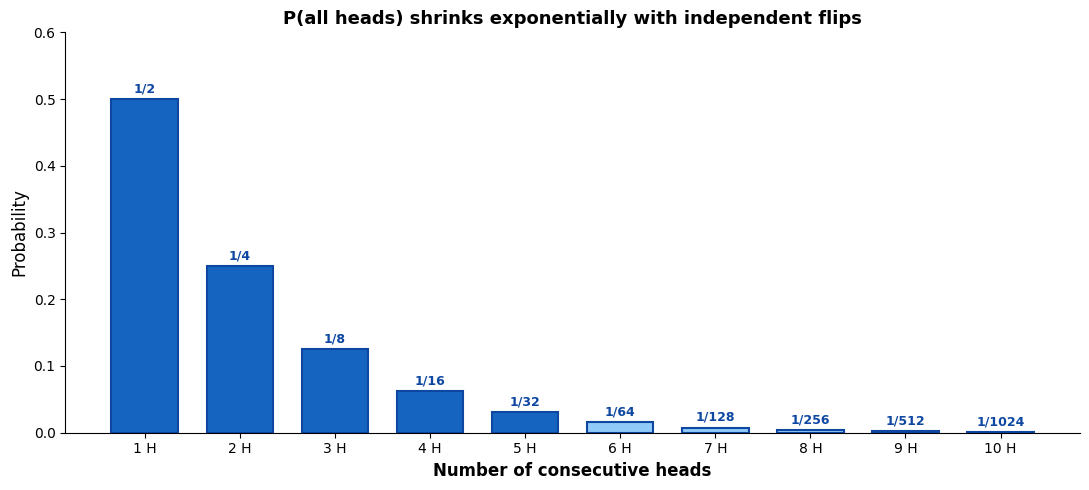

In [7]:
# --- Visual: probability shrinks with each independent flip ---

fig, ax = plt.subplots(figsize=(11, 5))

flips = list(range(1, 11))
probs = [p_head ** n for n in flips]

colors_bar = ['#1565C0' if n <= 5 else '#90CAF9' for n in flips]
bars = ax.bar(flips, probs, color=colors_bar, edgecolor='#0D47A1', lw=1.5, width=0.7)

for bar, prob, n in zip(bars, probs, flips):
    label = f'1/{2**n}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            label, ha='center', fontsize=9, fontweight='bold', color='#0D47A1')

ax.set_xlabel('Number of consecutive heads', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('P(all heads) shrinks exponentially with independent flips',
             fontsize=13, fontweight='bold')
ax.set_xticks(flips)
ax.set_xticklabels([f'{n} H' for n in flips])
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

---

## 5. Independence and Complements

If $A \perp B$, then $A$ and $B^C$ are also independent.

**Proof:**

$$P(A, B^C) = P(A) - P(A, B) \quad \text{(LOTP)}$$
$$= P(A) - P(A) \cdot P(B) \quad \text{(independence)}$$
$$= P(A) \cdot [1 - P(B)] = P(A) \cdot P(B^C) \;\checkmark$$

This also means $A^C \perp B$ and $A^C \perp B^C$.

In [8]:
# --- Verify independence with complements ---
# Use E=even, G=≤2 which are independent

E_comp = S - E  # odd numbers
G_comp = S - G  # numbers > 2

pairs = [
    ('E', 'G', E, G),
    ('E', 'G^C', E, G_comp),
    ('E^C', 'G', E_comp, G),
    ('E^C', 'G^C', E_comp, G_comp),
]

print("Independence extends to complements")
print("=" * 60)
print(f"E = even = {E},  G = ≤2 = {G}")
print(f"E^C = odd = {E_comp},  G^C = >2 = {G_comp}")
print()
print(f"{'Pair':<12} {'P(A∩B)':>10} {'P(A)·P(B)':>12} {'Independent?':>14}")
print("-" * 50)

for name_a, name_b, A, B in pairs:
    p_joint = P(A & B)
    p_prod = P(A) * P(B)
    indep = abs(p_joint - p_prod) < 1e-10
    print(f"{name_a + ',' + name_b:<12} {p_joint:>10.4f} {p_prod:>12.4f} {'✓ Yes':>14}" if indep
          else f"{name_a + ',' + name_b:<12} {p_joint:>10.4f} {p_prod:>12.4f} {'✗ No':>14}")

Independence extends to complements
E = even = {2, 4, 6},  G = ≤2 = {1, 2}
E^C = odd = {1, 3, 5},  G^C = >2 = {3, 4, 5, 6}

Pair             P(A∩B)    P(A)·P(B)   Independent?
--------------------------------------------------
E,G              0.1667       0.1667          ✓ Yes
E,G^C            0.3333       0.3333          ✓ Yes
E^C,G            0.1667       0.1667          ✓ Yes
E^C,G^C          0.3333       0.3333          ✓ Yes


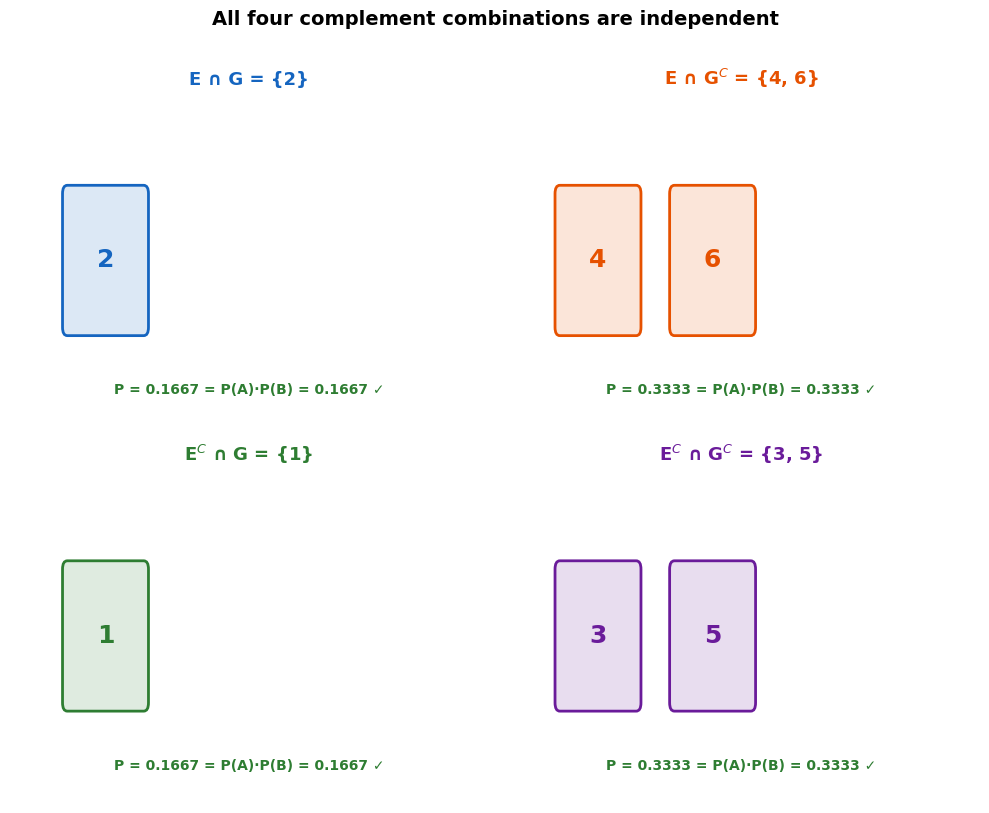

In [9]:
# --- Visual: 4 quadrants showing all complement combinations ---

E_comp = S - E  # odd numbers
G_comp = S - G  # numbers > 2

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

quadrants = [
    (E, G, 'E ∩ G', '#1565C0'),
    (E, G_comp, 'E ∩ G$^C$', '#E65100'),
    (E_comp, G, 'E$^C$ ∩ G', '#2E7D32'),
    (E_comp, G_comp, 'E$^C$ ∩ G$^C$', '#6A1B9A'),
]

for ax, (A, B, label, color) in zip(axes.flat, quadrants):
    intersection = A & B
    p_joint = P(intersection)
    p_prod = P(A) * P(B)

    # Show the die faces in the intersection
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 2)
    ax.axis('off')

    ax.set_title(f'{label} = {intersection}',
                 fontsize=13, fontweight='bold', color=color)

    # Draw die faces
    for i, face in enumerate(sorted(intersection)):
        x = 1 + i * 1.2
        rect = FancyBboxPatch((x - 0.4, 0.6), 0.8, 0.8,
            boxstyle='round,pad=0.05', facecolor=to_rgba(color, 0.15),
            edgecolor=color, lw=2)
        ax.add_patch(rect)
        ax.text(x, 1.0, str(face), ha='center', va='center',
                fontsize=18, fontweight='bold', color=color)

    ax.text(2.5, 0.2,
            f'P = {p_joint:.4f} = P(A)·P(B) = {p_prod:.4f} ✓',
            ha='center', fontsize=10, fontweight='bold', color='#2E7D32')

plt.suptitle('All four complement combinations are independent',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 6. Parallel Networks — A Classic Application

A network connects computer $A$ to computer $B$ through $n$ **independent** routers. Each router $i$ works with probability $p_i$. If **at least one** router works, the connection succeeds.

Let $F_i$ = router $i$ fails. Since routers are independent:

$$P(\text{connection}) = 1 - P(\text{all fail}) = 1 - \prod_{i=1}^{n} P(F_i) = 1 - \prod_{i=1}^{n} (1 - p_i)$$

In [10]:
# --- Parallel network example ---

router_probs = [0.95, 0.90, 0.85, 0.80]  # P(router i works)
n_routers = len(router_probs)

# P(all fail) = product of (1 - p_i)
p_all_fail = np.prod([1 - p for p in router_probs])
p_connection = 1 - p_all_fail

print("Parallel Network — Independent Routers")
print("=" * 55)
for i, p in enumerate(router_probs, 1):
    print(f"  Router {i}: P(works) = {p:.2f},  P(fails) = {1-p:.2f}")
print()
print(f"  P(all fail) = {'  ×  '.join(f'{1-p:.2f}' for p in router_probs)} = {p_all_fail:.6f}")
print(f"  P(connection) = 1 - {p_all_fail:.6f} = {p_connection:.6f}")
print(f"\n  Even with imperfect routers, redundancy gives {p_connection:.4%} reliability!")

Parallel Network — Independent Routers
  Router 1: P(works) = 0.95,  P(fails) = 0.05
  Router 2: P(works) = 0.90,  P(fails) = 0.10
  Router 3: P(works) = 0.85,  P(fails) = 0.15
  Router 4: P(works) = 0.80,  P(fails) = 0.20

  P(all fail) = 0.05  ×  0.10  ×  0.15  ×  0.20 = 0.000150
  P(connection) = 1 - 0.000150 = 0.999850

  Even with imperfect routers, redundancy gives 99.9850% reliability!


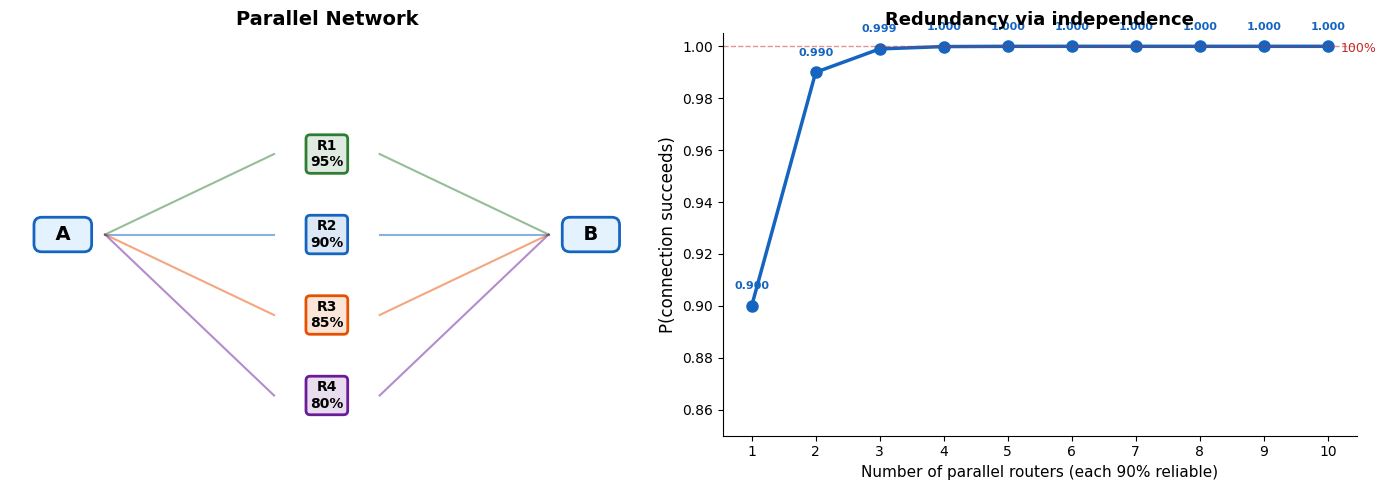

With just 3 routers at 90% each: 99.9000% reliability
With 5 routers at 90% each:      99.999000% reliability


In [11]:
# --- Visual: network reliability vs number of routers ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Network diagram
ax = axes[0]
ax.set_xlim(-1, 11)
ax.set_ylim(-0.5, n_routers + 0.5)
ax.axis('off')
ax.set_title('Parallel Network', fontsize=14, fontweight='bold')

# Computer A
ax.text(0, n_routers/2, '  A  ', fontsize=14, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0', lw=2))
# Computer B
ax.text(10, n_routers/2, '  B  ', fontsize=14, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0', lw=2))

router_colors = ['#2E7D32', '#1565C0', '#E65100', '#6A1B9A']
for i, (p, color) in enumerate(zip(router_probs, router_colors)):
    y = n_routers - 1 - i
    # Lines from A to router and router to B
    ax.plot([0.8, 4], [n_routers/2, y], color=color, lw=1.5, alpha=0.5)
    ax.plot([6, 9.2], [y, n_routers/2], color=color, lw=1.5, alpha=0.5)
    # Router box
    ax.text(5, y, f'R{i+1}\n{p:.0%}', fontsize=10, ha='center', va='center',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=to_rgba(color, 0.15),
                      edgecolor=color, lw=2))

# Panel 2: Reliability curve as we add routers (all with p=0.9)
ax = axes[1]
p_each = 0.90
n_range = np.arange(1, 11)
reliability = 1 - (1 - p_each) ** n_range

ax.plot(n_range, reliability, 'o-', color='#1565C0', lw=2.5, markersize=8)

for n, rel in zip(n_range, reliability):
    ax.annotate(f'{rel:.3f}', (n, rel), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=8, fontweight='bold', color='#1565C0')

ax.axhline(1.0, color='#C62828', ls='--', lw=1, alpha=0.5)
ax.text(10.2, 0.998, '100%', fontsize=9, color='#C62828')

ax.set_xlabel('Number of parallel routers (each 90% reliable)', fontsize=11)
ax.set_ylabel('P(connection succeeds)', fontsize=12)
ax.set_title('Redundancy via independence', fontsize=13, fontweight='bold')
ax.set_xticks(n_range)
ax.set_ylim(0.85, 1.005)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"With just 3 routers at 90% each: {1-(0.1)**3:.4%} reliability")
print(f"With 5 routers at 90% each:      {1-(0.1)**5:.6%} reliability")

---

## 7. Independence vs. Mutual Exclusion

These are **completely different** properties — and in fact, they're almost *opposites*!

| Property | Means | Formula |
|---|---|---|
| **Mutually Exclusive** | Events **cannot** happen together | $P(A \cap B) = 0$ |
| **Independent** | Events **don't influence** each other | $P(A \cap B) = P(A) \cdot P(B)$ |

If $P(A) > 0$ and $P(B) > 0$, then mutually exclusive events are **always dependent** (because knowing $A$ occurred tells you $B$ did not).

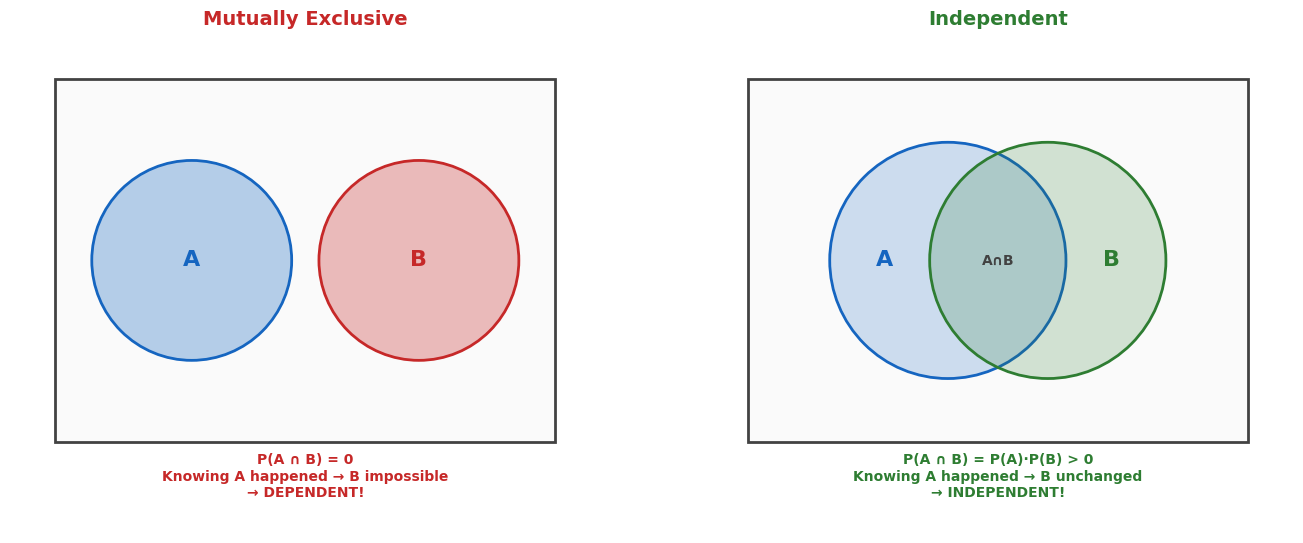

KEY: If P(A)>0 and P(B)>0, mutually exclusive ⟹ DEPENDENT.
     Mutually exclusive and independent are (almost) opposites!


In [12]:
# --- Visual comparison: Mutual Exclusion vs Independence ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Mutually Exclusive
ax = axes[0]
ax.set_xlim(-0.5, 6)
ax.set_ylim(-1, 4.5)
ax.set_aspect('equal')
ax.axis('off')

rect = patches.Rectangle((0, 0), 5.5, 4, lw=2,
                          edgecolor='#424242', facecolor='#FAFAFA')
ax.add_patch(rect)

# Two non-overlapping circles
c1 = plt.Circle((1.5, 2.0), 1.1, color='#1565C0', alpha=0.3)
c1b = plt.Circle((1.5, 2.0), 1.1, fill=False, edgecolor='#1565C0', lw=2)
c2 = plt.Circle((4.0, 2.0), 1.1, color='#C62828', alpha=0.3)
c2b = plt.Circle((4.0, 2.0), 1.1, fill=False, edgecolor='#C62828', lw=2)
ax.add_patch(c1); ax.add_patch(c1b)
ax.add_patch(c2); ax.add_patch(c2b)

ax.text(1.5, 2.0, 'A', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#1565C0')
ax.text(4.0, 2.0, 'B', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#C62828')

ax.set_title('Mutually Exclusive', fontsize=14, fontweight='bold', color='#C62828')
ax.text(2.75, -0.6, 'P(A ∩ B) = 0\nKnowing A happened → B impossible\n→ DEPENDENT!',
        fontsize=10, ha='center', color='#C62828', fontweight='bold')

# Panel 2: Independent (overlapping)
ax = axes[1]
ax.set_xlim(-0.5, 6)
ax.set_ylim(-1, 4.5)
ax.set_aspect('equal')
ax.axis('off')

rect = patches.Rectangle((0, 0), 5.5, 4, lw=2,
                          edgecolor='#424242', facecolor='#FAFAFA')
ax.add_patch(rect)

# Two overlapping circles
c1 = plt.Circle((2.2, 2.0), 1.3, color='#1565C0', alpha=0.2)
c1b = plt.Circle((2.2, 2.0), 1.3, fill=False, edgecolor='#1565C0', lw=2)
c2 = plt.Circle((3.3, 2.0), 1.3, color='#2E7D32', alpha=0.2)
c2b = plt.Circle((3.3, 2.0), 1.3, fill=False, edgecolor='#2E7D32', lw=2)
ax.add_patch(c1); ax.add_patch(c1b)
ax.add_patch(c2); ax.add_patch(c2b)

ax.text(1.5, 2.0, 'A', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#1565C0')
ax.text(4.0, 2.0, 'B', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#2E7D32')
ax.text(2.75, 2.0, 'A∩B', fontsize=10, ha='center', va='center',
        fontweight='bold', color='#424242')

ax.set_title('Independent', fontsize=14, fontweight='bold', color='#2E7D32')
ax.text(2.75, -0.6, 'P(A ∩ B) = P(A)·P(B) > 0\nKnowing A happened → B unchanged\n→ INDEPENDENT!',
        fontsize=10, ha='center', color='#2E7D32', fontweight='bold')

plt.tight_layout()
plt.show()

print("KEY: If P(A)>0 and P(B)>0, mutually exclusive ⟹ DEPENDENT.")
print("     Mutually exclusive and independent are (almost) opposites!")

---

## 8. Pairwise vs. Mutual Independence

With three or more events, **pairwise independence** (every pair is independent) does **not** imply **mutual independence** (product rule holds for all subsets).

Here's a famous counterexample.

In [13]:
# --- Pairwise independent but NOT mutually independent ---
# Two fair coin flips: C1, C2
# A = C1 is Heads, B = C2 is Heads, C = C1 XOR C2 (exactly one heads)

# Sample space for two coins: {HH, HT, TH, TT}
sample_space = ['HH', 'HT', 'TH', 'TT']
A = {'HH', 'HT'}  # C1 = H
B = {'HH', 'TH'}  # C2 = H
C = {'HT', 'TH'}  # exactly one H (XOR)

def Pr(event):
    return len(event) / len(sample_space)

print("Pairwise vs. Mutual Independence")
print("=" * 60)
print(f"Two coins: S = {sample_space}")
print(f"A = C₁ is H = {A}")
print(f"B = C₂ is H = {B}")
print(f"C = exactly one H (XOR) = {C}")
print()

# Check pairwise
pairs = [('A', 'B', A, B), ('A', 'C', A, C), ('B', 'C', B, C)]
print("Pairwise checks:")
for name1, name2, X, Y in pairs:
    p_joint = Pr(X & Y)
    p_prod = Pr(X) * Pr(Y)
    ok = abs(p_joint - p_prod) < 1e-10
    print(f"  P({name1}∩{name2}) = {p_joint:.4f},  "
          f"P({name1})·P({name2}) = {p_prod:.4f}  "
          f"→ {'✓ Independent' if ok else '✗ Dependent'}")

# Check triple (mutual)
print()
triple = A & B & C
p_triple = Pr(triple)
p_product = Pr(A) * Pr(B) * Pr(C)
ok_triple = abs(p_triple - p_product) < 1e-10
print(f"Mutual check:")
print(f"  P(A∩B∩C) = P({triple}) = {p_triple:.4f}")
print(f"  P(A)·P(B)·P(C) = {Pr(A):.2f}·{Pr(B):.2f}·{Pr(C):.2f} = {p_product:.4f}")
print(f"  → {'✓ Mutually independent' if ok_triple else '✗ NOT mutually independent'}")
print()
print("All pairs are independent, but the triple is NOT!")
print("Pairwise independence ≠ Mutual independence.")

Pairwise vs. Mutual Independence
Two coins: S = ['HH', 'HT', 'TH', 'TT']
A = C₁ is H = {'HH', 'HT'}
B = C₂ is H = {'HH', 'TH'}
C = exactly one H (XOR) = {'TH', 'HT'}

Pairwise checks:
  P(A∩B) = 0.2500,  P(A)·P(B) = 0.2500  → ✓ Independent
  P(A∩C) = 0.2500,  P(A)·P(C) = 0.2500  → ✓ Independent
  P(B∩C) = 0.2500,  P(B)·P(C) = 0.2500  → ✓ Independent

Mutual check:
  P(A∩B∩C) = P(set()) = 0.0000
  P(A)·P(B)·P(C) = 0.50·0.50·0.50 = 0.1250
  → ✗ NOT mutually independent

All pairs are independent, but the triple is NOT!
Pairwise independence ≠ Mutual independence.


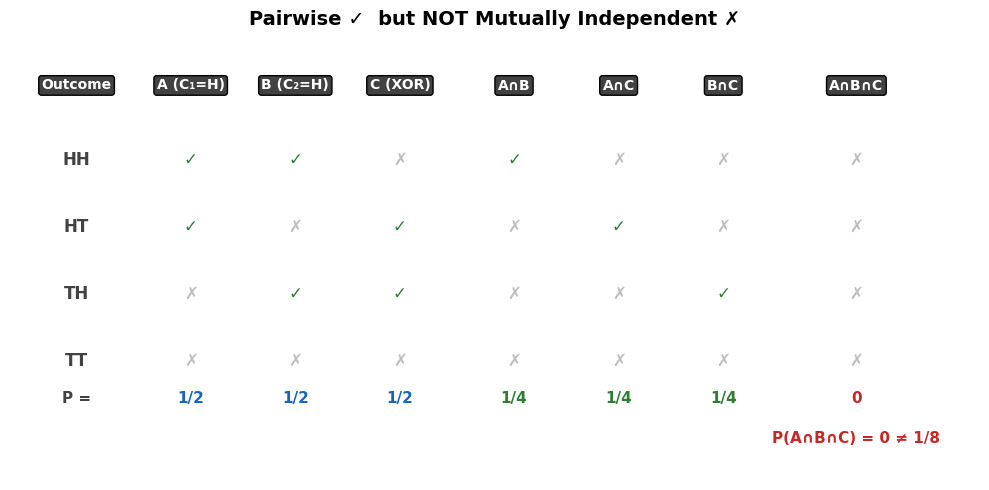

In [14]:
# --- Visual: pairwise vs mutual with color-coded outcome table ---

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Table header
col_labels = ['Outcome', 'A (C₁=H)', 'B (C₂=H)', 'C (XOR)', 'A∩B', 'A∩C', 'B∩C', 'A∩B∩C']
col_x = [0.5, 1.7, 2.8, 3.9, 5.1, 6.2, 7.3, 8.7]

for j, (label, x) in enumerate(zip(col_labels, col_x)):
    ax.text(x, 4.5, label, ha='center', va='center', fontsize=10, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#424242'))

# Data rows
for i, outcome in enumerate(sample_space):
    y = 3.5 - i * 0.9
    in_A = outcome in A
    in_B = outcome in B
    in_C = outcome in C

    row_data = [
        outcome,
        '✓' if in_A else '✗',
        '✓' if in_B else '✗',
        '✓' if in_C else '✗',
        '✓' if in_A and in_B else '✗',
        '✓' if in_A and in_C else '✗',
        '✓' if in_B and in_C else '✗',
        '✓' if in_A and in_B and in_C else '✗',
    ]

    for j, (val, x) in enumerate(zip(row_data, col_x)):
        color = '#2E7D32' if val == '✓' else '#BDBDBD'
        if j == 0:
            color = '#424242'
        ax.text(x, y, val, ha='center', va='center', fontsize=12,
                fontweight='bold', color=color)

# Probability row
y_prob = 0.3
prob_data = ['P =', '1/2', '1/2', '1/2', '1/4', '1/4', '1/4', '0']
prob_colors = ['#424242', '#1565C0', '#1565C0', '#1565C0',
               '#2E7D32', '#2E7D32', '#2E7D32', '#C62828']
for j, (val, x, color) in enumerate(zip(prob_data, col_x, prob_colors)):
    ax.text(x, y_prob, val, ha='center', va='center', fontsize=11,
            fontweight='bold', color=color)

# Annotation
ax.text(8.7, -0.3, 'P(A∩B∩C) = 0 ≠ 1/8', fontsize=11, ha='center',
        fontweight='bold', color='#C62828')

ax.set_title('Pairwise ✓  but NOT Mutually Independent ✗',
             fontsize=14, fontweight='bold')
ax.set_xlim(-0.2, 10)
ax.set_ylim(-0.8, 5.2)
plt.tight_layout()
plt.show()

---

## 9. Conditional Independence

Events $E_1, E_2, \ldots, E_n$ are **conditionally independent** given event $F$ if:

> $$P(E_1, E_2, \ldots, E_n | F) = \prod_{i=1}^{n} P(E_i | F)$$

**Warning:** Conditional independence given $F$ does **not** imply unconditional independence!

And vice versa: unconditionally independent events may become dependent when conditioned on another event.

In [15]:
# --- Conditional independence example ---
# Two students, Alice and Bob, take a test.
# F = test is easy
# A = Alice passes, B = Bob passes
# Given the difficulty level, Alice and Bob perform independently.
# But unconditionally, they are correlated (both do well on easy tests).

P_F = 0.6       # P(test is easy)
P_A_given_F = 0.9   # P(Alice passes | easy)
P_B_given_F = 0.85  # P(Bob passes | easy)
P_A_given_Fc = 0.4  # P(Alice passes | hard)
P_B_given_Fc = 0.3  # P(Bob passes | hard)

# Conditional independence given F:
# P(A,B|F) = P(A|F)·P(B|F)
P_AB_given_F = P_A_given_F * P_B_given_F  # by conditional independence
P_AB_given_Fc = P_A_given_Fc * P_B_given_Fc

# Unconditional: Use LOTP
# P(A,B) = P(A,B|F)P(F) + P(A,B|F^c)P(F^c)
P_AB = P_AB_given_F * P_F + P_AB_given_Fc * (1 - P_F)

# P(A) and P(B) unconditionally
P_A = P_A_given_F * P_F + P_A_given_Fc * (1 - P_F)
P_B = P_B_given_F * P_F + P_B_given_Fc * (1 - P_F)

P_A_times_B = P_A * P_B

print("Conditional Independence Example: Student Test Results")
print("=" * 60)
print(f"P(Easy test) = {P_F}")
print(f"P(Alice passes | Easy) = {P_A_given_F},  P(Alice passes | Hard) = {P_A_given_Fc}")
print(f"P(Bob passes | Easy)   = {P_B_given_F},  P(Bob passes | Hard)   = {P_B_given_Fc}")
print()
print("Given test difficulty, A and B are conditionally independent:")
print(f"  P(A,B | Easy) = P(A|Easy)·P(B|Easy) = {P_A_given_F}·{P_B_given_F} = {P_AB_given_F:.4f}")
print(f"  P(A,B | Hard) = P(A|Hard)·P(B|Hard) = {P_A_given_Fc}·{P_B_given_Fc} = {P_AB_given_Fc:.4f}")
print()
print("But UNCONDITIONALLY:")
print(f"  P(A) = {P_A:.4f}")
print(f"  P(B) = {P_B:.4f}")
print(f"  P(A)·P(B) = {P_A_times_B:.4f}")
print(f"  P(A,B) = {P_AB:.4f}  (via LOTP)")
print(f"  P(A,B) {'==' if abs(P_AB - P_A_times_B)<1e-10 else '≠'} P(A)·P(B)")
print(f"  → Unconditionally DEPENDENT (correlation = {P_AB - P_A_times_B:+.4f})")
print()
print("If Alice passed, the test was probably easy,")
print("which makes Bob more likely to pass too → dependence!")

Conditional Independence Example: Student Test Results
P(Easy test) = 0.6
P(Alice passes | Easy) = 0.9,  P(Alice passes | Hard) = 0.4
P(Bob passes | Easy)   = 0.85,  P(Bob passes | Hard)   = 0.3

Given test difficulty, A and B are conditionally independent:
  P(A,B | Easy) = P(A|Easy)·P(B|Easy) = 0.9·0.85 = 0.7650
  P(A,B | Hard) = P(A|Hard)·P(B|Hard) = 0.4·0.3 = 0.1200

But UNCONDITIONALLY:
  P(A) = 0.7000
  P(B) = 0.6300
  P(A)·P(B) = 0.4410
  P(A,B) = 0.5070  (via LOTP)
  P(A,B) ≠ P(A)·P(B)
  → Unconditionally DEPENDENT (correlation = +0.0660)

If Alice passed, the test was probably easy,
which makes Bob more likely to pass too → dependence!


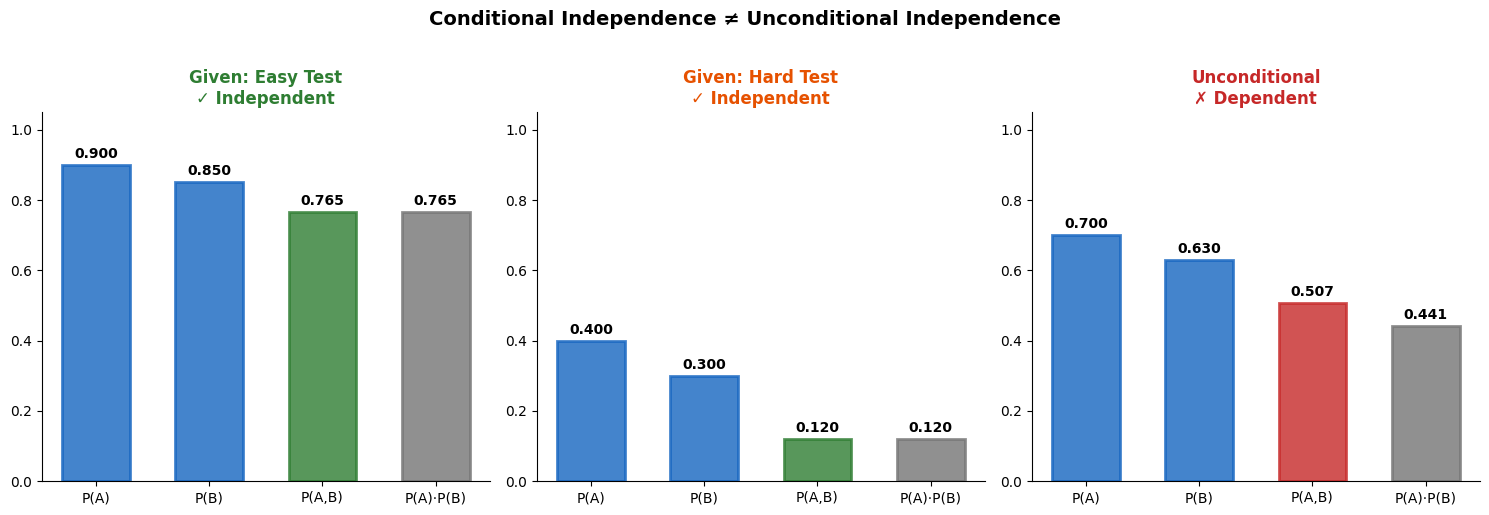

In [16]:
# --- Visual: conditional vs unconditional ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

data = [
    ('Given: Easy Test', P_A_given_F, P_B_given_F, P_AB_given_F,
     P_A_given_F * P_B_given_F, '#2E7D32'),
    ('Given: Hard Test', P_A_given_Fc, P_B_given_Fc, P_AB_given_Fc,
     P_A_given_Fc * P_B_given_Fc, '#E65100'),
    ('Unconditional', P_A, P_B, P_AB, P_A_times_B, '#C62828'),
]

for ax, (title, pa, pb, pab, papb, color) in zip(axes, data):
    indep = abs(pab - papb) < 1e-10
    labels = ['P(A)', 'P(B)', 'P(A,B)', 'P(A)·P(B)']
    values = [pa, pb, pab, papb]
    bar_colors = ['#1565C0', '#1565C0',
                  '#2E7D32' if indep else '#C62828',
                  '#757575']

    bars = ax.bar(labels, values, color=bar_colors, alpha=0.8,
                  edgecolor=bar_colors, lw=2, width=0.6)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

    status = '✓ Independent' if indep else '✗ Dependent'
    ax.set_title(f'{title}\n{status}', fontsize=12, fontweight='bold', color=color)
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Conditional Independence ≠ Unconditional Independence',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 10. Testing for Independence — A Simulation Approach

With real-world data, perfect independence is rare. We simulate to see how close to independent two events are.

In [17]:
# --- Monte Carlo: testing independence of two dice ---

N_sim = 500_000
rng = np.random.default_rng(42)

die1 = rng.integers(1, 7, size=N_sim)
die2 = rng.integers(1, 7, size=N_sim)

# E = die1 is even, F = die2 ≤ 3 (separate dice → independent)
E_sim = die1 % 2 == 0
F_sim = die2 <= 3

P_E_sim = E_sim.mean()
P_F_sim = F_sim.mean()
P_EF_sim = (E_sim & F_sim).mean()
P_E_given_F_sim = (E_sim & F_sim).sum() / F_sim.sum()

print(f"Monte Carlo Independence Test ({N_sim:,} trials)")
print("=" * 55)
print(f"E = die1 is even,  F = die2 ≤ 3  (different dice)")
print()
print(f"  P(E)     = {P_E_sim:.4f}  (exact: 0.5000)")
print(f"  P(F)     = {P_F_sim:.4f}  (exact: 0.5000)")
print(f"  P(E ∩ F) = {P_EF_sim:.4f}  (exact: 0.2500)")
print(f"  P(E)·P(F)= {P_E_sim * P_F_sim:.4f}")
print(f"  P(E|F)   = {P_E_given_F_sim:.4f}  (exact: 0.5000)")
print(f"\n  P(E|F) ≈ P(E)? {abs(P_E_given_F_sim - P_E_sim) < 0.01}  → Independent ✓")

# Now test dependent events: E = die1 even, G = die1 > 3 (SAME die → dependent!)
G_sim = die1 > 3
P_G_sim = G_sim.mean()
P_EG_sim = (E_sim & G_sim).mean()
P_E_given_G_sim = (E_sim & G_sim).sum() / G_sim.sum()

print(f"\n--- Comparison: Dependent events ---")
print(f"E = die1 is even,  G = die1 > 3  (same die!)")
print(f"  P(E)     = {P_E_sim:.4f}")
print(f"  P(G)     = {P_G_sim:.4f}  (exact: 0.5000)")
print(f"  P(E ∩ G) = {P_EG_sim:.4f}  (exact: {2/6:.4f}, only {{4,6}})")
print(f"  P(E)·P(G)= {P_E_sim * P_G_sim:.4f}")
print(f"  P(E|G)   = {P_E_given_G_sim:.4f}  (exact: {2/3:.4f})")
print(f"\n  P(E|G) ≈ P(E)? {abs(P_E_given_G_sim - P_E_sim) < 0.01}  → Dependent ✗")
print(f"  Knowing die1 > 3 makes \"even\" more likely ({2/3:.2%} vs 50%)!")

Monte Carlo Independence Test (500,000 trials)
E = die1 is even,  F = die2 ≤ 3  (different dice)

  P(E)     = 0.4996  (exact: 0.5000)
  P(F)     = 0.5008  (exact: 0.5000)
  P(E ∩ F) = 0.2510  (exact: 0.2500)
  P(E)·P(F)= 0.2502
  P(E|F)   = 0.5012  (exact: 0.5000)

  P(E|F) ≈ P(E)? True  → Independent ✓

--- Comparison: Dependent events ---
E = die1 is even,  G = die1 > 3  (same die!)
  P(E)     = 0.4996
  P(G)     = 0.5005  (exact: 0.5000)
  P(E ∩ G) = 0.3331  (exact: 0.3333, only {4,6})
  P(E)·P(G)= 0.2500
  P(E|G)   = 0.6656  (exact: 0.6667)

  P(E|G) ≈ P(E)? False  → Dependent ✗
  Knowing die1 > 3 makes "even" more likely (66.67% vs 50%)!


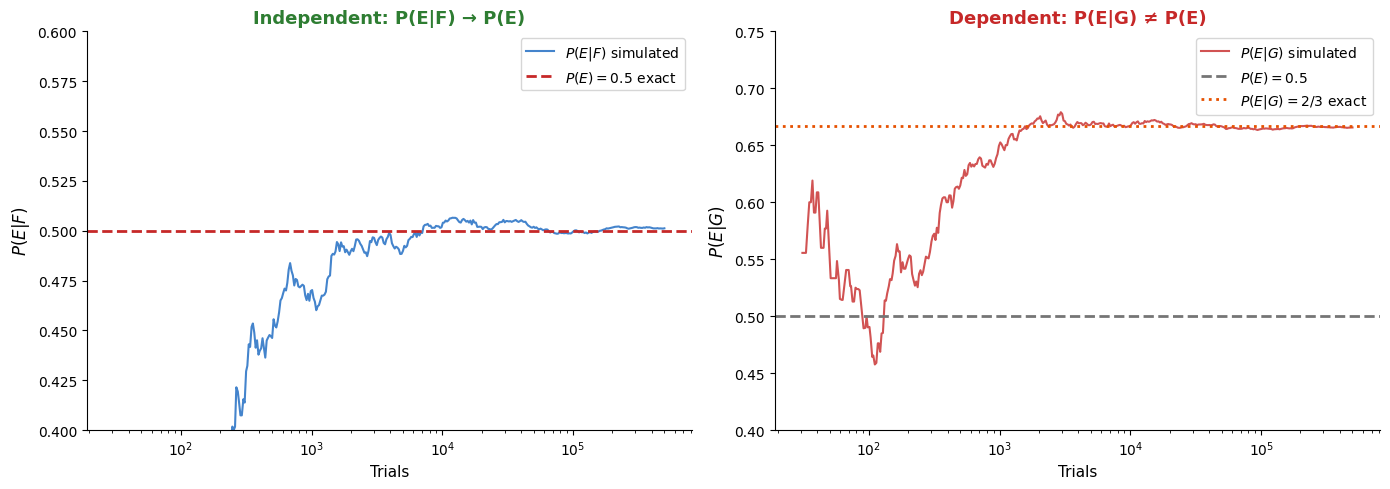

In [18]:
# --- Visual: convergence of P(E|F) to P(E) for independent events ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

checkpoints = np.unique(np.logspace(1.5, np.log10(N_sim), 400).astype(int))

# Independent: P(E|F) → P(E)
ax = axes[0]
cum_E_and_F = np.cumsum(E_sim & F_sim)
cum_F = np.cumsum(F_sim)
# Avoid division by zero
safe = cum_F[checkpoints - 1] > 0
cp = checkpoints[safe]
ratio = cum_E_and_F[cp - 1] / cum_F[cp - 1]

ax.plot(cp, ratio, color='#1565C0', lw=1.5, alpha=0.8, label='$P(E|F)$ simulated')
ax.axhline(0.5, color='#C62828', ls='--', lw=2, label='$P(E) = 0.5$ exact')
ax.set_xscale('log')
ax.set_xlabel('Trials', fontsize=11)
ax.set_ylabel('$P(E|F)$', fontsize=12)
ax.set_title('Independent: P(E|F) → P(E)', fontsize=13, fontweight='bold', color='#2E7D32')
ax.legend(fontsize=10)
ax.set_ylim(0.4, 0.6)
ax.spines[['top', 'right']].set_visible(False)

# Dependent: P(E|G) ≠ P(E) where G = die1 > 3
ax = axes[1]
cum_E_and_G = np.cumsum(E_sim & G_sim)
cum_G = np.cumsum(G_sim)
safe_g = cum_G[checkpoints - 1] > 0
cp_g = checkpoints[safe_g]
ratio_g = cum_E_and_G[cp_g - 1] / cum_G[cp_g - 1]

ax.plot(cp_g, ratio_g, color='#C62828', lw=1.5, alpha=0.8, label='$P(E|G)$ simulated')
ax.axhline(0.5, color='#757575', ls='--', lw=2, label='$P(E) = 0.5$')
ax.axhline(2/3, color='#E65100', ls=':', lw=2, label='$P(E|G) = 2/3$ exact')
ax.set_xscale('log')
ax.set_xlabel('Trials', fontsize=11)
ax.set_ylabel('$P(E|G)$', fontsize=12)
ax.set_title('Dependent: P(E|G) ≠ P(E)', fontsize=13, fontweight='bold', color='#C62828')
ax.legend(fontsize=10)
ax.set_ylim(0.4, 0.75)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## 11. How to Establish Independence

In practice, you establish independence in one of two ways:

1. **Mathematically:** Show that $P(E|F) = P(E)$ or $P(E,F) = P(E) \cdot P(F)$
2. **By assumption:** If it's *reasonable* that one event doesn't influence another, **assume** independence as a *modeling assumption*

The second approach is incredibly common in CS and ML. For example, **Naïve Bayes** assumes all features are conditionally independent given the class — this is usually wrong, but the resulting classifier works surprisingly well!

> "All models are wrong, but some are useful." — George Box

---

## 12. Summary

| Concept | Formula |
|---|---|
| **Independence (definition)** | $P(E \mid F) = P(E)$ |
| **Product rule** | $P(A,B) = P(A) \cdot P(B)$ |
| **Symmetry** | $E \perp F \iff F \perp E$ |
| **Generalized** | $P(E_1, \ldots, E_n) = \prod P(E_i)$ for all subsets |
| **Complements** | $A \perp B \implies A \perp B^C, A^C \perp B, A^C \perp B^C$ |
| **Parallel reliability** | $P(\text{success}) = 1 - \prod (1 - p_i)$ |
| **Conditional independence** | $P(E_1, \ldots, E_n \mid F) = \prod P(E_i \mid F)$ |

### Key Takeaways

1. Independence means **knowing one event tells you nothing** about the other
2. The product rule $P(A,B) = P(A) \cdot P(B)$ is the most practical test
3. **Mutual exclusion ≠ independence** — they're almost opposites
4. **Pairwise independence ≠ mutual independence** — check all subsets!
5. Conditional independence given $F$ does **not** imply unconditional independence
6. Independence is often a **modeling assumption**, not a proven fact